In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances

In [2]:
df = pd.read_csv("accepted_2007_to_2018Q4.csv")

/var/folders/5t/wm0jdjw92v52gkkc3sl6d1th0000gn/T/ipykernel_25313/4199025983.py:1: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("accepted_2007_to_2018Q4.csv")


In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='str', length=151)

In [8]:
df.isnull().sum()

id                             0
member_id                2260701
loan_amnt                     33
funded_amnt                   33
funded_amnt_inv               33
                          ...   
settlement_status        2226455
settlement_date          2226455
settlement_amount        2226455
settlement_percentage    2226455
settlement_term          2226455
Length: 151, dtype: int64

In [10]:
df.shape

(2260701, 151)

In [20]:
features = ['loan_amnt', 'annual_inc', 'dti', 
            'fico_range_low', 'int_rate', 'installment', 'revol_util']

df_model = df[features + ['id','grade', 'loan_status']].dropna()

In [35]:
df_model = df_model.reset_index(drop=True)

In [22]:
df_model.isnull().sum()

loan_amnt         0
annual_inc        0
dti               0
fico_range_low    0
int_rate          0
installment       0
revol_util        0
id                0
grade             0
loan_status       0
dtype: int64

In [26]:
for grade in ['A', 'C', 'E']:
    print(f"\n--- Grade {grade} candidates ---")
    print(df_model[df_model['grade'] == grade][features + ['id', 'loan_status']].head(5))


--- Grade A candidates ---
    loan_amnt  annual_inc    dti  fico_range_low  int_rate  installment  \
8     10000.0     85000.0  13.07           685.0      6.49       306.45   
14    28000.0     92000.0  21.60           720.0      6.49       858.05   
15     9600.0     60000.0  22.44           695.0      7.49       298.58   
16    25000.0    109000.0  26.02           745.0      7.49       777.55   
24     6000.0    100000.0  13.28           695.0      7.49       186.61   

    revol_util        id loan_status  
8         34.5  68466926  Fully Paid  
14        64.5  68466961  Fully Paid  
15        59.4  68354783  Fully Paid  
16        54.3  68466916  Fully Paid  
24        72.0  68476715  Fully Paid  

--- Grade C candidates ---
    loan_amnt  annual_inc    dti  fico_range_low  int_rate  installment  \
0      3600.0     55000.0   5.91           675.0     13.99       123.03   
1     24700.0     65000.0  16.06           715.0     11.99       820.28   
3     35000.0    110000.0  17.06  

In [27]:
query_ids = [68466961, 68426831, 68436934]
query_loans = df_model[df_model['id'].isin(query_ids)]
print(query_loans[features + ['id', 'grade', 'loan_status']])

    loan_amnt  annual_inc   dti  fico_range_low  int_rate  installment  \
5     11950.0     34000.0  10.2           690.0     13.44       405.18   
14    28000.0     92000.0  21.6           720.0      6.49       858.05   
79    23975.0     70000.0  33.2           685.0     19.89       633.73   

    revol_util        id grade  loan_status  
5         68.4  68426831     C   Fully Paid  
14        64.5  68466961     A   Fully Paid  
79        94.9  68436934     E  Charged Off  


In [28]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_model[features])

In [36]:
results = {}
for loan_id in query_ids:
    query_idx = df_model[df_model['id'] == loan_id].index[0]
    
    query_vector = scaled_features[query_idx].reshape(1, -1)
    
    distances = euclidean_distances(query_vector, scaled_features)[0]
    
    df_model['distance'] = distances
    
    top10 = (df_model[df_model['id'] != loan_id]
             .sort_values('distance')
             .head(10)[features + ['id', 'grade', 'loan_status', 'distance']])
    
    results[loan_id] = top10
    print(f"\n Top 10 most similar loans to Loan ID {loan_id}:")
    print(top10)
df_model.drop(columns=['distance'], inplace=True)


 Top 10 most similar loans to Loan ID 68466961:
         loan_amnt  annual_inc    dti  fico_range_low  int_rate  installment  \
378816     28000.0     86000.0  22.01           720.0      6.03       852.20   
1768332    28000.0    100000.0  22.56           715.0      6.62       859.71   
2068064    28000.0     73900.0  21.30           715.0      6.72       860.98   
1032011    28000.0     84000.0  20.12           715.0      6.49       858.05   
195564     28000.0     73000.0  20.84           715.0      6.24       854.87   
2180977    28000.0     80000.0  20.15           720.0      7.49       870.85   
169631     28000.0     90000.0  18.85           715.0      6.24       854.87   
1880351    27000.0    100000.0  21.31           720.0      7.62       841.36   
351168     28000.0    103000.0  20.77           715.0      5.93       850.93   
165231     28000.0     84838.0  19.92           720.0      5.32       843.22   

         revol_util         id grade  loan_status  distance  
378816  

In [30]:
df_model.drop(columns=['distance'], inplace=True)

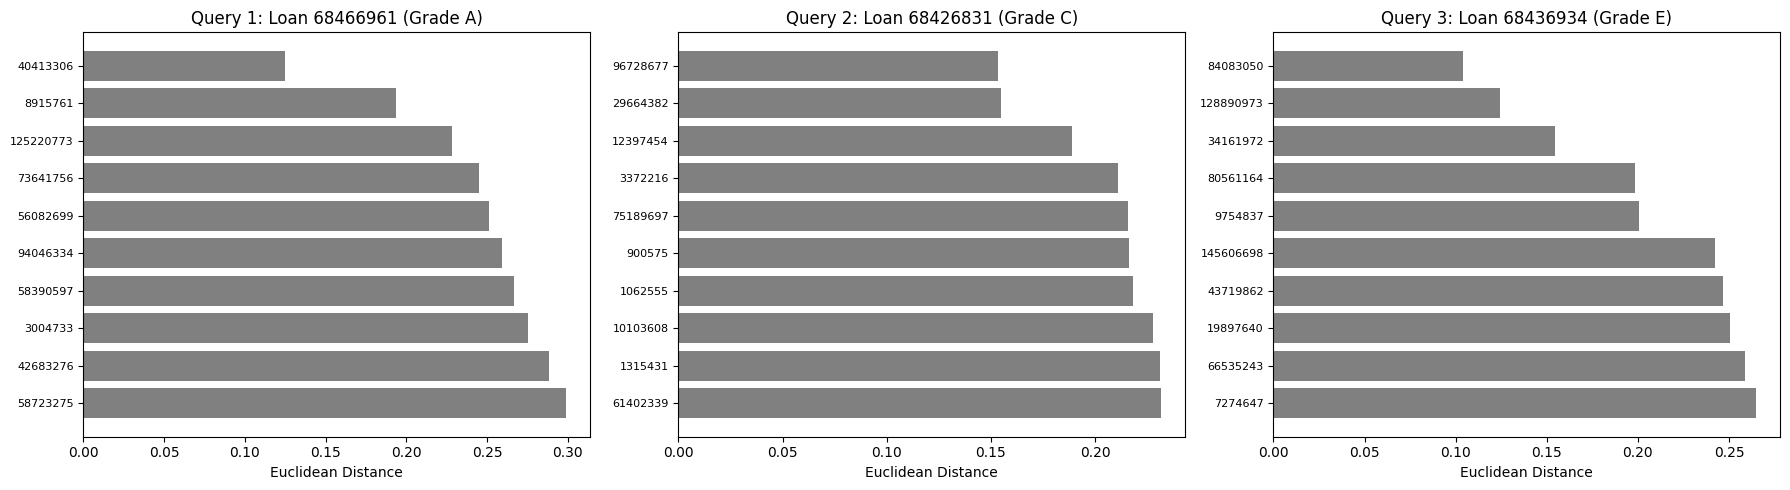

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = {68466961: 'Query 1: Loan 68466961 (Grade A)',68426831: 'Query 2: Loan 68426831 (Grade C)',68436934: 'Query 3: Loan 68436934 (Grade E)'}

for ax, loan_id in zip(axes, query_ids):
    top10 = results[loan_id]
    ax.barh(range(10), top10['distance'], color='grey')
    ax.set_yticks(range(10))
    ax.set_yticklabels([str(i) for i in top10['id']], fontsize=8)
    ax.set_xlabel('Euclidean Distance')
    ax.set_title(titles[loan_id])
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('distances.png', dpi=150)
plt.show()

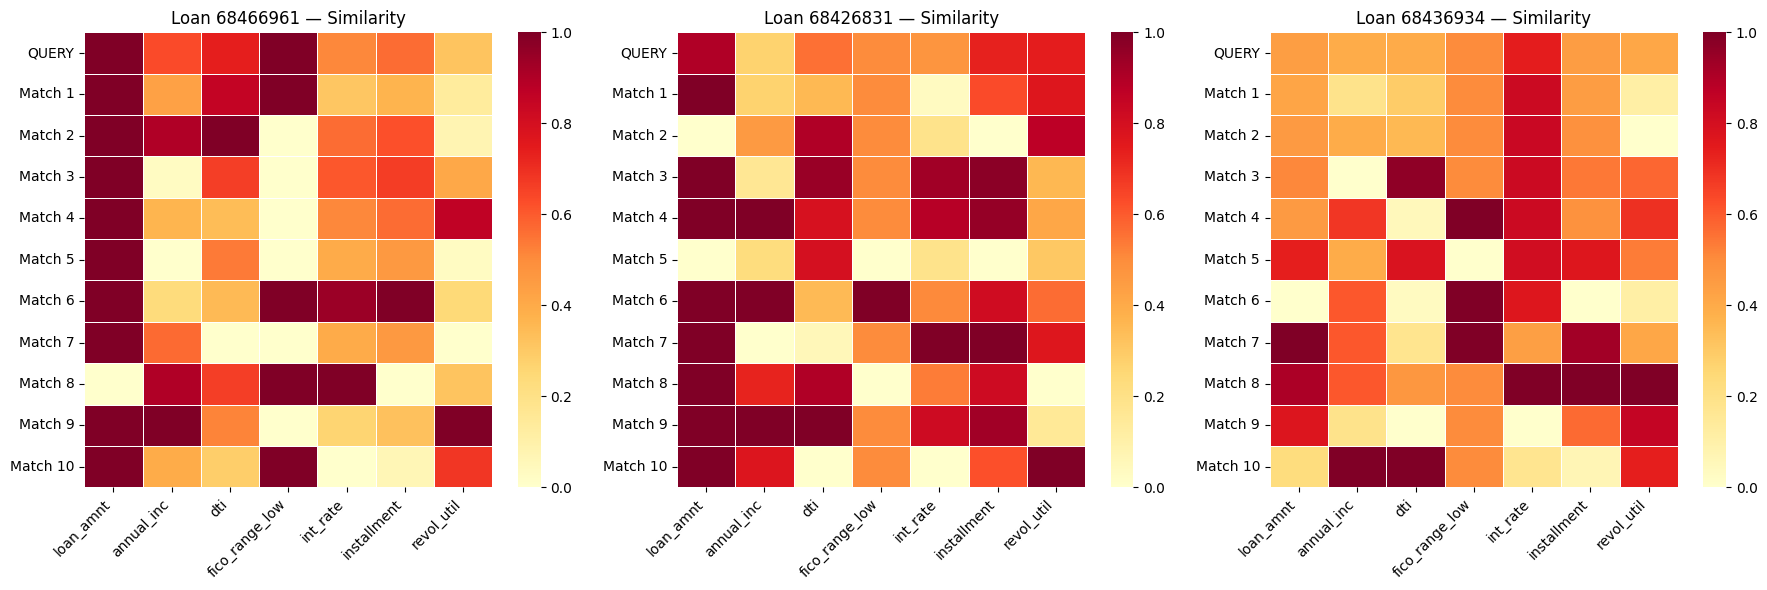

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, loan_id in zip(axes, query_ids):
    query_row = df_model[df_model['id'] == loan_id][features]
    top10 = results[loan_id][features]
    combined = pd.concat([query_row, top10], ignore_index=True)
    combined.index = ['QUERY'] + [f'Match {i+1}' for i in range(10)]
    
    combined_norm = (combined - combined.min()) / (combined.max() - combined.min())
    
    sns.heatmap(combined_norm, annot=False, cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title(f'Loan {loan_id} — Similarity')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()